In [1]:
!nvidia-smi
# !lscpu | head -n 15

Tue Aug 20 01:20:27 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.01             Driver Version: 535.183.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3090        Off | 00000000:01:00.0 Off |                  N/A |
| 73%   83C    P2             262W / 350W |  18852MiB / 24576MiB |    100%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from pydicom import dcmread
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm


import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils import data

import torch.nn.functional as F
from torchvision.utils import make_grid, save_image

from matplotlib import rcParams

import matplotlib.patches as patches
from math import ceil

In [3]:
label_data = pd.read_csv('./rsna-dataset/stage_2_train_labels.csv')
columns = ['patientId', 'Target']
all_data = label_data

label_data = label_data.filter(columns)
label_data.head(5)
#print(all_data)

,patientId,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,0
4,00436515-870c-4b36-a041-de91049b9ab4,1


In [4]:
train_labels, val_labels = train_test_split(label_data.values, test_size=0.1)
print(train_labels.shape)
print(val_labels.shape)

(27204, 2)
(3023, 2)


In [5]:
print(f'patientId: {train_labels[0][0]}, Target: {train_labels[0][1]}')

patientId: ae5ace0c-758d-4f0d-9acd-3f4817b0634c, Target: 1


In [6]:
train_f = './rsna-dataset/train_images'
test_f = './rsna-dataset/test_images'

train_paths = [os.path.join(train_f, image[0]) for image in train_labels]
val_paths = [os.path.join(train_f, image[0]) for image in val_labels]

print(len(train_paths))
print(len(val_paths))

27204
3023


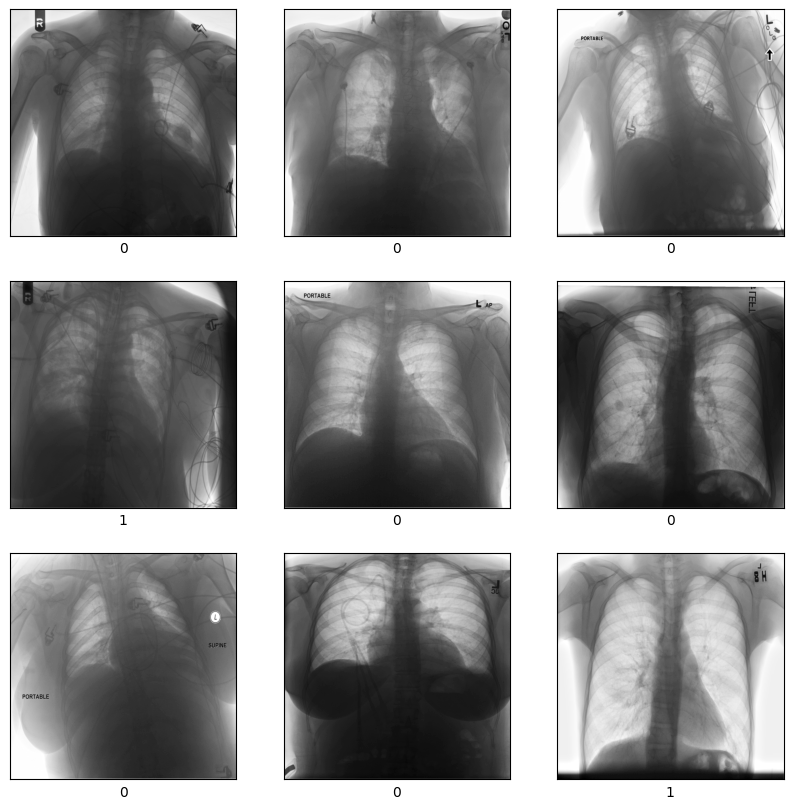

In [7]:
def imshow(num_to_show=9):
    
    plt.figure(figsize=(10,10))
    
    for i in range(num_to_show):
        plt.subplot(3, 3, i+1)
        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        
        img_dcm = dcmread(f'{train_paths[i+20]}.dcm')
        img_np = img_dcm.pixel_array
        plt.imshow(img_np, cmap=plt.cm.binary)
        plt.xlabel(train_labels[i+20][1])

imshow()

In [8]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.Resize(224),
    transforms.ToTensor()])

In [9]:
class Dataset(data.Dataset):
    
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
    
    def __getitem__(self, index):
        image = dcmread(f'{self.paths[index]}.dcm')
        image = image.pixel_array
        image = image / 255.0

        image = (255*image).clip(0, 255).astype(np.uint8)
        image = Image.fromarray(image).convert('RGB')

        label = self.labels[index][1]
        
        if self.transform is not None:
            image = self.transform(image)
        
        
        name = self.paths[index].split("/")[-1]
        GH = all_data['patientId']==name
        FIL = all_data[GH]
        #print("From the datset loader, name", name)
        box = [FIL['x'].values[0], FIL['y'].values[0], FIL['width'].values[0], FIL['height'].values[0]]
            
        return image, label, box
    
    def __len__(self):
        
        return len(self.paths)

1 [239.0, 517.0, 183.0, 147.0]


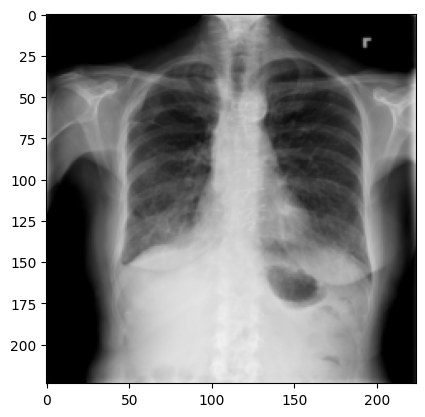

In [10]:
train_dataset = Dataset(train_paths, train_labels, transform=transform)
image = iter(train_dataset)
#print(train_dataset.paths)
img, label, box = next(image)
print(label, box)
#print(f'Tensor:{img}, Label:{label}')
img = np.transpose(img, (1, 2, 0))
plt.imshow(img)

In [11]:
img.shape

torch.Size([224, 224, 3])

## Prepare training and validation dataloader

In [27]:
train_dataset = Dataset(train_paths, train_labels, transform=transform)
val_dataset = Dataset(val_paths, val_labels, transform=transform)
train_loader = data.DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=128, shuffle=False)

## Check dataloader

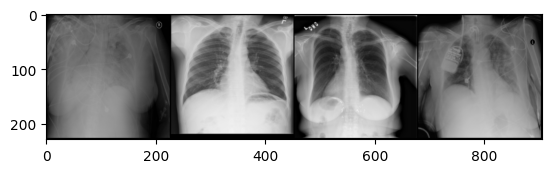

In [28]:
batch = iter(train_loader)
images, labels, _ = next(batch)

image_grid = torchvision.utils.make_grid(images[:4])
image_np = image_grid.numpy()
img = np.transpose(image_np, (1, 2, 0))
plt.imshow(img)

## Specify device object

In [29]:
device = torch.device('cuda:7' if torch.cuda.is_available() else 'cpu')

<a id="model"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Loading a Pre-trained ResNet18 Model and its Fine-tuning</b></div>    

In [30]:
model = torchvision.models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model.fc = nn.Linear(num_ftrs, 2)

model.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [31]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

<a id="train"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Training the Model</b></div>    

In [33]:
if 1 or 0:
    num_epochs = 20
    # Train the model
    total_step = len(train_loader)
    for epoch in range(num_epochs):
        # Training step
        for i, (images, labels, _) in tqdm(enumerate(train_loader)):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (i + 1) % 2000 == 0:
                print("Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}"
                      .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))

        # Validation step
        correct = 0
        total = 0
        for images, labels, _ in tqdm(val_loader):
            images = images.to(device)
            labels = labels.to(device)
            predictions = model(images)
            _, predicted = torch.max(predictions, 1)
            total += labels.size(0)
            correct += (labels == predicted).sum()
        print(f'Epoch: {epoch + 1}/{num_epochs}, Val_Acc: {100 * correct / total}')

213it [1:04:39, 18.22s/it]
100%|██████████| 24/24 [06:11<00:00, 15.48s/it]


Epoch: 1/20, Val_Acc: 80.41680145263672


213it [1:16:28, 21.54s/it]
100%|██████████| 24/24 [08:32<00:00, 21.36s/it]


Epoch: 2/20, Val_Acc: 81.80615234375


213it [1:08:08, 19.19s/it]
100%|██████████| 24/24 [05:21<00:00, 13.39s/it]


...

Epoch: 18/20, Val_Acc: 86.43731689453125


213it [1:07:11, 18.93s/it]
100%|██████████| 24/24 [08:52<00:00, 22.18s/it]


Epoch: 19/20, Val_Acc: 86.90042877197266


213it [1:13:23, 20.67s/it]
100%|██████████| 24/24 [09:21<00:00, 23.38s/it]

Epoch: 20/20, Val_Acc: 86.43731689453125


<a id="test"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Testing the Model</b></div>    

In [34]:
if 1 or 0:
    model.eval()

    correct = 0
    total = 0
    for images, labels, _ in tqdm(val_loader):
        images = images.to(device)
        labels = labels.to(device)
        predictions = model(images)
        _, predicted = torch.max(predictions, 1)
        total += labels.size(0)
        correct += (labels == predicted).sum()
    print(f'Val_Acc: {100 * correct / total}')

100%|██████████| 24/24 [08:50<00:00, 22.09s/it]

Val_Acc: 87.82666015625


<a id="save"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Save the Model Weights</b></div>      

In [36]:
# torch.save(model.state_dict(), './rsna-dataset/my_models_weights.pth')
# torch.save(model, './rsna-dataset/my_model.pth')
print("Model and weights saved.")

Model and weights saved.


<a id="load"></a>
# <div style="padding:20px;color:white;margin:0;font-size:20px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Loading Saved Model</b></div>     

In [39]:
model = torch.load('./rsna-dataset/my_model.pth')

In [40]:
model.to(device)
model.eval()

correct = 0
total = 0  
for images, labels, _ in tqdm(val_loader):
    images = images.to(device)
    labels = labels.to(device)
    predictions = model(images)
    _, predicted = torch.max(predictions, 1)
    total += labels.size(0)
    correct += (labels == predicted).sum()
print(f'Val_Acc: {100*correct/total}')

100%|██████████| 24/24 [09:53<00:00, 24.74s/it]

Val_Acc: 87.2643051147461


torch.Size([224, 224, 3])
Label :  1 [705.0, 556.0, 167.0, 247.0]


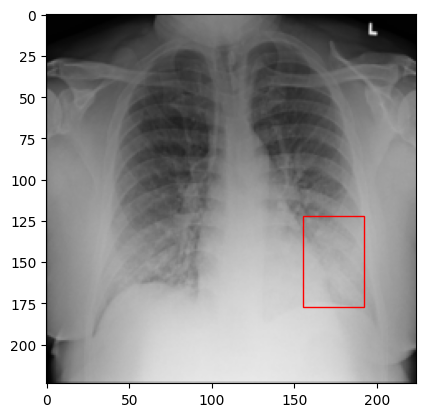

In [41]:
# Load test image
label = 0
while(label==0):
    pil_img, label, box = next(image)

fig,ax = plt.subplots(1)

Orig_img_size = 1024
img_size = 224

# 'r' means relative. 'c' means center.
rx = ceil(box[0]*img_size/Orig_img_size)
ry = ceil(box[1]*img_size/Orig_img_size)
rw = ceil(box[2]*img_size/Orig_img_size)
rh = ceil(box[3]*img_size/Orig_img_size)


pil_img = np.transpose(pil_img, (1, 2, 0))
print(pil_img.shape)
rect = patches.Rectangle((rx, ry), rw, rh, linewidth=1, edgecolor='r', facecolor='none')
ax.imshow(pil_img)
ax.add_patch(rect)
print("Label : ", label, box)